In [1]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=["feature1", "feature2", "feature3"])
df["target"] = 1

mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=["feature1", "feature2", "feature3"])
df1["target"] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40, random_state=23)

print(df.head())

    feature1  feature2  feature3  target
18 -0.331617 -1.632386  0.619114       1
23  1.010229  1.437830  2.327788       0
8   0.241106 -0.952510 -0.136267       1
22  1.676860  4.187503 -0.080565       0
33  2.823378 -0.332863  2.637391       0


In [2]:
df.head()

,feature1,feature2,feature3,target
18,-0.331617,-1.632386,0.619114,1
23,1.010229,1.437830,2.327788,0
8,0.241106,-0.952510,-0.136267,1
22,1.676860,4.187503,-0.080565,0
33,2.823378,-0.332863,2.637391,0


In [3]:
%pip install plotly


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install -U nbformat


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

fig = px.scatter_3d(
    df,
    x="feature1",
    y="feature2",
    z="feature3",
    color=df["target"].astype(str)
)

fig.update_traces(
    marker=dict(
        size=12,
        line=dict(width=2, color="DarkSlateGrey")
    ),
    selector=dict(mode="markers")
)

fig.show()

In [6]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [7]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [8]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [9]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [10]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

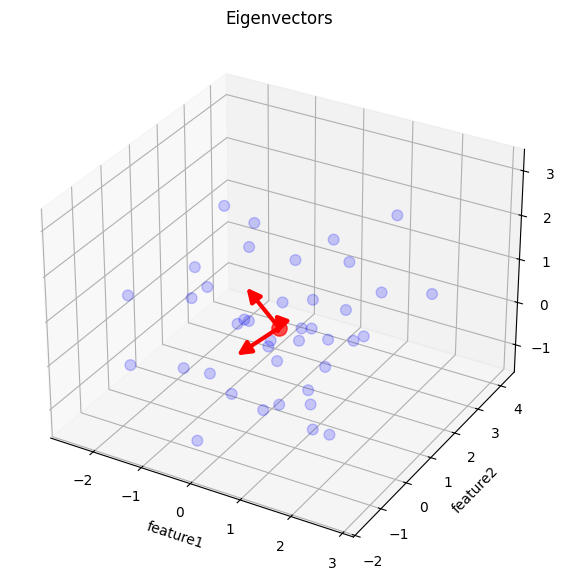

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

# -----------------------------
# Create sample dataset
# -----------------------------
np.random.seed(23)

mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=["feature1", "feature2", "feature3"])
df["target"] = 1

mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=["feature1", "feature2", "feature3"])
df1["target"] = 0

df = pd.concat([df, df1], ignore_index=True)
df = df.sample(40, random_state=23)

# -----------------------------
# PCA-style eigen decomposition
# -----------------------------
X = df[["feature1", "feature2", "feature3"]].values
mean_vec = X.mean(axis=0)

# center the data
X_centered = X - mean_vec

# covariance matrix
cov_mat = np.cov(X_centered, rowvar=False)

# eigen decomposition
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)

# -----------------------------
# Custom 3D Arrow class
# -----------------------------
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d

        if renderer is None:
            return np.min(zs3d)

        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

# all points
ax.scatter(
    df["feature1"],
    df["feature2"],
    df["feature3"],
    s=60,
    color="blue",
    alpha=0.2
)

# mean point
ax.scatter(
    mean_vec[0],
    mean_vec[1],
    mean_vec[2],
    s=120,
    color="red",
    alpha=0.7
)

# eigenvectors
for v in eigen_vectors.T:
    a = Arrow3D(
        [mean_vec[0], mean_vec[0] + v[0]],
        [mean_vec[1], mean_vec[1] + v[1]],
        [mean_vec[2], mean_vec[2] + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="r"
    )
    ax.add_artist(a)

ax.set_xlabel("feature1")
ax.set_ylabel("feature2")
ax.set_zlabel("feature3")
plt.title("Eigenvectors")
plt.show()

In [12]:
pc = eigen_vectors[0:2]
pc

array([[-0.61002583, -0.69239396,  0.3853039 ],
       [-0.53982115,  0.00718615, -0.84174906]])

In [13]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,1.571096,-0.353855,1
1,-0.714905,-2.494424,0
2,0.459927,-0.022297,1
3,-3.953371,-0.807297,0
4,-0.475664,-3.746533,0


In [14]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()